# 🌲 Random Forest Gunshot Classifier — Training & Evaluation

This notebook loads the feature CSV and:
1. Creates a **balanced 150/150 test set** (150 gunshots + 150 non-gunshots)
2. Trains a **Random Forest** classifier on the remaining data
3. Reports comprehensive evaluation metrics
4. Plots **Learning Curves** to diagnose overfitting/underfitting
5. Runs **Cross-Validation** for robust scoring
6. Saves a **Predictions CSV** with actual vs predicted labels

In [1]:
!pip install -q scikit-learn pandas numpy seaborn matplotlib

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import learning_curve, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    log_loss, r2_score, roc_auc_score, roc_curve, matthews_corrcoef,
)

SEED = 42
np.random.seed(SEED)
print('✅ All imports loaded.')

✅ All imports loaded.


## Step 1: Load Dataset

In [3]:
CSV_PATH = Path(r'c:\Desktop\Data-Cleaner\Data\Output\dataset_features.csv')
OUTPUT_DIR = Path(r'c:\Desktop\Data-Cleaner\Data\Output')

df = pd.read_csv(CSV_PATH)
print(f'📊 Dataset loaded: {len(df)} samples')
print(f'   Class 0 (non-gunshot): {(df["label"] == 0).sum()}')
print(f'   Class 1 (gunshot)    : {(df["label"] == 1).sum()}')
print(f'   Features             : {len([c for c in df.columns if c.startswith("mfcc_")])}')
df.head()

📊 Dataset loaded: 10368 samples
   Class 0 (non-gunshot): 6230
   Class 1 (gunshot)    : 4138
   Features             : 80


,file_path,trimmed_duration_ms,label,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,...,mfcc_70,mfcc_71,mfcc_72,mfcc_73,mfcc_74,mfcc_75,mfcc_76,mfcc_77,mfcc_78,mfcc_79
0,c:\Desktop\Data-Cleaner\Data\audio\16000\4-181...,5000.00,0,-584.86615,67.272750,-5.909483,16.873217,8.442039,14.823366,6.674617,...,3.218015,4.608699,4.050599,3.394491,3.145775,5.859838,4.350021,4.878862,2.999315,4.219984
1,c:\Desktop\Data-Cleaner\Data\audio\1-67432-A-2...,5000.00,0,-156.12706,-30.381441,-2.520434,10.042790,19.838245,10.902749,-0.367381,...,3.059962,3.383876,3.242513,3.057203,3.687129,3.045339,3.391944,2.762360,2.966041,3.237614
2,c:\Desktop\Data-Cleaner\Data\Output\trimmed_gu...,7407.17,1,-580.84960,120.700750,-5.382522,32.750847,4.447424,11.394693,4.349497,...,4.130706,3.603146,3.279809,3.347042,3.039511,3.718764,2.967764,3.088598,2.866388,2.802322
3,c:\Desktop\Data-Cleaner\Data\Output\trimmed_gu...,1578.96,1,-576.44670,17.956106,-11.108670,2.149039,-12.501011,-0.905995,-5.445512,...,2.838675,2.634250,2.655603,3.036999,2.199270,1.886445,2.920240,1.517998,1.687609,2.067153
4,c:\Desktop\Data-Cleaner\Data\Output\trimmed_gu...,789.48,1,-630.71277,30.392002,-2.860079,1.925278,2.473357,1.391537,3.274570,...,1.542561,1.328898,2.045225,1.503679,1.630705,1.548071,1.902350,1.629477,1.458646,1.132490


## Step 2: Balanced 150/150 Train-Test Split

In [ ]:
TEST_PER_CLASS = 4000

df_0 = df[df['label'] == 0].copy()
df_1 = df[df['label'] == 1].copy()

test_0 = df_0.sample(n=TEST_PER_CLASS, random_state=SEED)
test_1 = df_1.sample(n=TEST_PER_CLASS, random_state=SEED)
test_df = pd.concat([test_0, test_1]).sample(frac=1, random_state=SEED)

train_df = df.drop(test_df.index).sample(frac=1, random_state=SEED)

feature_cols = [c for c in df.columns if c.startswith('mfcc_')]

X_train = train_df[feature_cols].values
y_train = train_df['label'].values
X_test  = test_df[feature_cols].values
y_test  = test_df['label'].values

print(f'📦 Train set: {len(train_df)} samples  '
      f'(Class 0: {(y_train==0).sum()}, Class 1: {(y_train==1).sum()})')
print(f'📦 Test  set: {len(test_df)} samples  '
      f'(Class 0: {(y_test==0).sum()}, Class 1: {(y_test==1).sum()})')

📦 Train set: 10068 samples  (Class 0: 6080, Class 1: 3988)
📦 Test  set: 300 samples  (Class 0: 150, Class 1: 150)


## Step 3: Feature Scaling

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print('✅ Features scaled with StandardScaler.')

✅ Features scaled with StandardScaler.


## Step 4: 🌲 Train Random Forest

In [6]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=SEED,
    n_jobs=-1
)

print('⏳ Training Random Forest ...')
rf.fit(X_train_scaled, y_train)
print('✅ Random Forest training complete!')
print(f'   Number of trees  : {rf.n_estimators}')
print(f'   Max depth        : {rf.max_depth}')
print(f'   Features used    : {rf.n_features_in_}')

⏳ Training Random Forest ...
✅ Random Forest training complete!
   Number of trees  : 200
   Max depth        : None
   Features used    : 80


## Step 5: 📈 Evaluation Metrics

In [7]:
y_pred  = rf.predict(X_test_scaled)
y_proba = rf.predict_proba(X_test_scaled)

acc      = accuracy_score(y_test, y_pred)
prec     = precision_score(y_test, y_pred)
rec      = recall_score(y_test, y_pred)
f1       = f1_score(y_test, y_pred)
logloss  = log_loss(y_test, y_proba)
r2       = r2_score(y_test, y_pred)
roc_auc  = roc_auc_score(y_test, y_proba[:, 1])
mcc      = matthews_corrcoef(y_test, y_pred)

metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score',
               'Log Loss', 'R² Score', 'ROC-AUC', 'Matthews Corr. Coeff.'],
    'Score': [acc, prec, rec, f1, logloss, r2, roc_auc, mcc]
})
metrics_df['Score'] = metrics_df['Score'].round(4)

print('\n' + '='*50)
print('     📊 RANDOM FOREST EVALUATION METRICS')
print('='*50)
for _, row in metrics_df.iterrows():
    icon = '✅' if row['Metric'] not in ['Log Loss'] or row['Score'] < 0.5 else '⚠️'
    print(f'  {icon} {row["Metric"]:<25} {row["Score"]:>10.4f}')
print('='*50)
metrics_df


     📊 RANDOM FOREST EVALUATION METRICS
  ✅ Accuracy                      0.9933
  ✅ Precision                     0.9933
  ✅ Recall                        0.9933
  ✅ F1 Score                      0.9933
  ✅ Log Loss                      0.0582
  ✅ R² Score                      0.9733
  ✅ ROC-AUC                       1.0000
  ✅ Matthews Corr. Coeff.         0.9867


,Metric,Score
0,Accuracy,0.9933
1,Precision,0.9933
2,Recall,0.9933
3,F1 Score,0.9933
4,Log Loss,0.0582
5,R² Score,0.9733
6,ROC-AUC,1.0000
7,Matthews Corr. Coeff.,0.9867


In [8]:
print('\n📋 Classification Report:\n')
print(classification_report(
    y_test, y_pred,
    target_names=['Non-Gunshot (0)', 'Gunshot (1)']
))


📋 Classification Report:

                 precision    recall  f1-score   support

Non-Gunshot (0)       0.99      0.99      0.99       150
    Gunshot (1)       0.99      0.99      0.99       150

       accuracy                           0.99       300
      macro avg       0.99      0.99      0.99       300
   weighted avg       0.99      0.99      0.99       300



## Step 6: 📉 Confusion Matrix

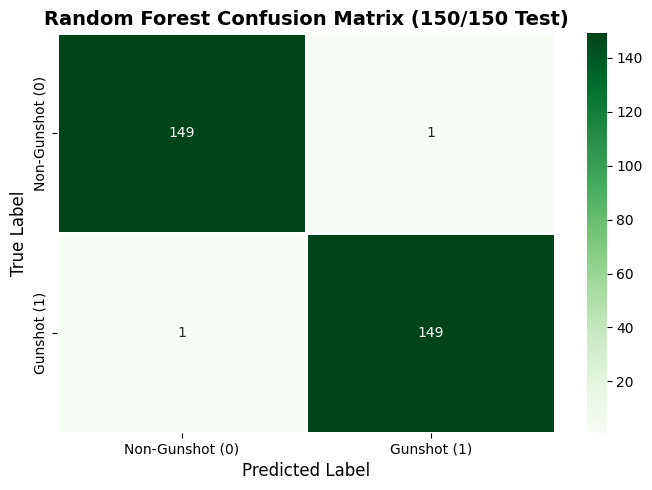

In [9]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Non-Gunshot (0)', 'Gunshot (1)'],
            yticklabels=['Non-Gunshot (0)', 'Gunshot (1)'],
            linewidths=1, linecolor='white', ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Random Forest Confusion Matrix (150/150 Test)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 7: 📈 ROC Curve

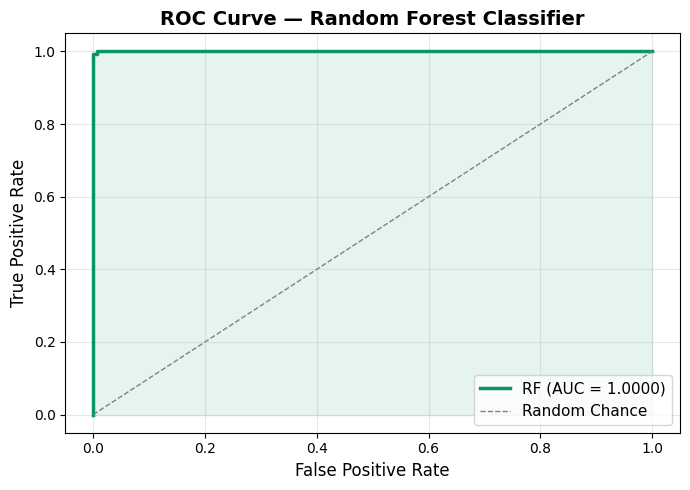

In [10]:
fpr, tpr, _ = roc_curve(y_test, y_proba[:, 1])
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='#059669', lw=2.5, label=f'RF (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Chance')
ax.fill_between(fpr, tpr, alpha=0.1, color='#059669')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Random Forest Classifier', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 8: 📊 Learning Curves (Overfitting / Underfitting Diagnostic)

The learning curve plots **training accuracy vs validation accuracy** as the training set grows.  
- If both converge at high accuracy → **good fit**  
- If training is high but validation is low → **overfitting**  
- If both are low → **underfitting**

⏳ Computing learning curves (this may take a minute) ...


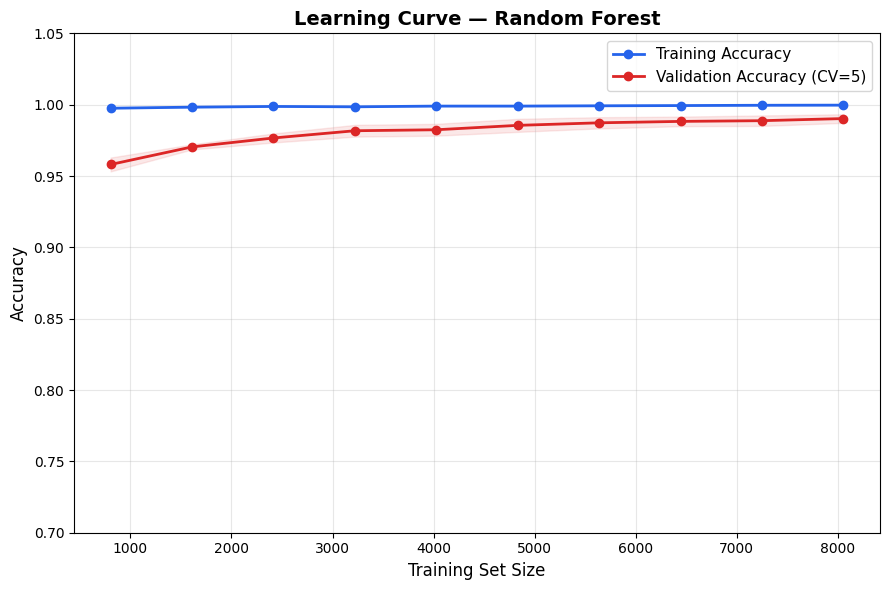


📊 Final gap (train - val): 0.0094
✅ Model appears well-fitted!


In [11]:
print('⏳ Computing learning curves (this may take a minute) ...')

train_sizes, train_scores, val_scores = learning_curve(
    rf, X_train_scaled, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=SEED
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(train_sizes, train_mean, 'o-', color='#2563eb', lw=2, label='Training Accuracy')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='#2563eb')
ax.plot(train_sizes, val_mean, 'o-', color='#dc2626', lw=2, label='Validation Accuracy (CV=5)')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='#dc2626')

ax.set_xlabel('Training Set Size', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Learning Curve — Random Forest', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(0.7, 1.05)
plt.tight_layout()
plt.show()

gap = train_mean[-1] - val_mean[-1]
print(f'\n📊 Final gap (train - val): {gap:.4f}')
if gap > 0.05:
    print('⚠️  Potential OVERFITTING detected (gap > 5%)')
elif val_mean[-1] < 0.85:
    print('⚠️  Potential UNDERFITTING detected (val accuracy < 85%)')
else:
    print('✅ Model appears well-fitted!')

## Step 9: 🔄 Cross-Validation Scores

In [12]:
print('⏳ Running 5-fold Stratified Cross-Validation ...')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_scores = cross_val_score(rf, X_train_scaled, y_train, cv=cv, scoring='accuracy', n_jobs=-1)

print(f'\n📊 Cross-Validation Results (5-Fold):')
for i, score in enumerate(cv_scores, 1):
    print(f'   Fold {i}: {score:.4f}')
print(f'\n   Mean Accuracy : {cv_scores.mean():.4f}')
print(f'   Std Deviation : {cv_scores.std():.4f}')

# Also do F1
cv_f1 = cross_val_score(rf, X_train_scaled, y_train, cv=cv, scoring='f1', n_jobs=-1)
print(f'\n   Mean F1 Score : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')

⏳ Running 5-fold Stratified Cross-Validation ...

📊 Cross-Validation Results (5-Fold):
   Fold 1: 0.9896
   Fold 2: 0.9891
   Fold 3: 0.9916
   Fold 4: 0.9916
   Fold 5: 0.9901

   Mean Accuracy : 0.9904
   Std Deviation : 0.0010

   Mean F1 Score : 0.9878 ± 0.0013


## Step 10: 💾 Save Test Predictions CSV

Saves a CSV with `file_path`, `actual_label`, `predicted_label`, `predicted_proba_gunshot` for the test set.

In [13]:
predictions_df = test_df[['file_path', 'label']].copy()
predictions_df = predictions_df.rename(columns={'label': 'actual_label'})
predictions_df['predicted_label'] = y_pred
predictions_df['predicted_proba_gunshot'] = y_proba[:, 1].round(4)
predictions_df['correct'] = (predictions_df['actual_label'] == predictions_df['predicted_label'])

pred_csv_path = OUTPUT_DIR / 'rf_test_predictions.csv'
predictions_df.to_csv(pred_csv_path, index=False)

n_correct = predictions_df['correct'].sum()
n_wrong   = (~predictions_df['correct']).sum()
print(f'💾 Predictions saved to: {pred_csv_path}')
print(f'   Correct   : {n_correct} / {len(predictions_df)}')
print(f'   Incorrect : {n_wrong} / {len(predictions_df)}')
print(f'\n🔍 Misclassified samples:')
misclassified = predictions_df[~predictions_df['correct']]
if len(misclassified) == 0:
    print('   None! Perfect predictions on test set.')
else:
    display(misclassified)

💾 Predictions saved to: c:\Desktop\Data-Cleaner\Data\Output\rf_test_predictions.csv
   Correct   : 298 / 300
   Incorrect : 2 / 300

🔍 Misclassified samples:


,file_path,actual_label,predicted_label,predicted_proba_gunshot,correct
538,c:\Desktop\Data-Cleaner\Data\Output\trimmed_gu...,1,0,0.4249,False
6971,c:\Desktop\Data-Cleaner\Data\audio\16000\2-102...,0,1,0.5497,False


## Step 11: 📊 Metrics Bar Chart

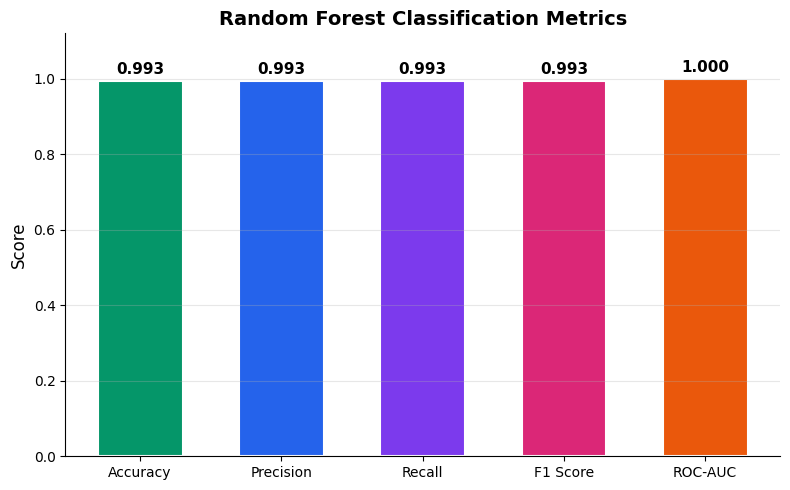

In [14]:
plot_metrics = metrics_df[metrics_df['Metric'].isin(
    ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
)].copy()

colors = ['#059669', '#2563eb', '#7c3aed', '#db2777', '#ea580c']
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(plot_metrics['Metric'], plot_metrics['Score'],
              color=colors, edgecolor='white', linewidth=1.5, width=0.6)
for bar, val in zip(bars, plot_metrics['Score']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Random Forest Classification Metrics', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

---
## ✅ Summary

The **Random Forest** model has been trained and evaluated:
- **Metrics table** with Accuracy, Precision, Recall, F1, Log Loss, R², ROC-AUC, MCC
- **Confusion Matrix** heatmap
- **ROC Curve** with AUC
- **Learning Curve** to diagnose overfitting/underfitting
- **5-Fold Cross-Validation** for robust scoring
- **Predictions CSV** with actual vs predicted labels saved to `Data/Output/rf_test_predictions.csv`